<h2>Welle um ein Kreis-Hindernis:</h2>

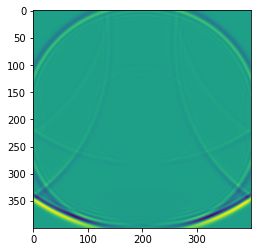

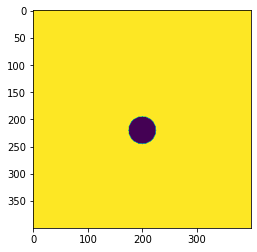

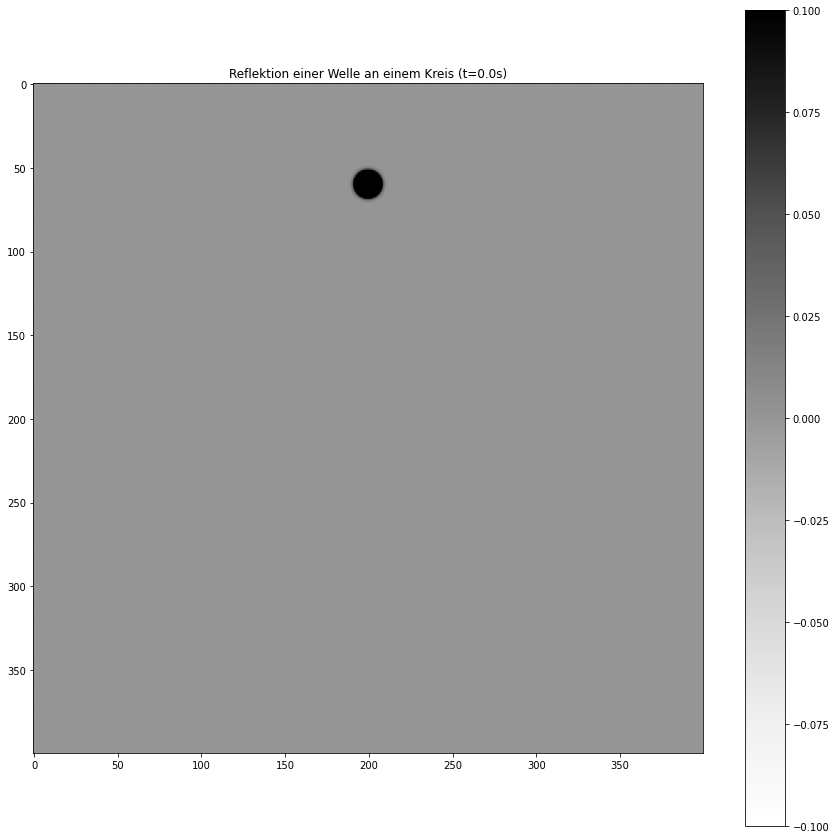

In [10]:
import numpy
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot
import wellen_simulation

heigth = 400
width = 400 #m
d_x = 1 #m
d_y = 1 #m
time = 0.35 #s
d_t = 0.0005

n_x = int(width/d_x)
n_y = int(heigth/d_y)
n_t = int(time/d_t)
seitenverhältnis = n_y/n_x


v = 1000 * numpy.ones((n_y, n_x))
r = 25
for x in range(n_x):
    for y in range(n_y):   
        a = 220
        b = 200
        h = a/d_y - y
        w = b/d_x -x
        if numpy.sqrt((h)**2 + (w)**2) <= r:
            v[y, x] = 0

u = numpy.zeros((n_y, n_x, n_t))

gauss = wellen_simulation.point_source(amplitude_gauss=10, mu_x=0.5, mu_y=0.15, sigma=0.007, n_x=n_x, n_y=n_y)
u[:, :, 0] = gauss
u[:, :, 1] = gauss


u = wellen_simulation.wellen_simulieren_ohne_wände(u, v, n_t, d_t, d_x, d_y)
matplotlib.pyplot.imshow(u[:,:,-1])
matplotlib.pyplot.show()
matplotlib.pyplot.imshow(v)

# Funktion für die Animation
def update(frame):
    print(frame, end='\r')
    im.set_array(u[:,:,frame])
    cbar.mappable.set_array(u[:, :, frame])
    cbar.mappable.set_clim(-0.1,0.1)
    ax.set_title("Reflektion einer Welle an einem Kreis (t=" + str(numpy.round(frame/n_t, 2)) + "s)")
    return im,
 
# Erstelle das Figure-Objekt und die Axes-Objekte
skalierung = 15
fig, ax = plt.subplots(figsize=(skalierung, skalierung*seitenverhältnis))
im = ax.imshow(u[:,:,-1], cmap='Greys')
cbar = plt.colorbar(im)

# Erstelle die Animation
ani = FuncAnimation(fig, update, frames=n_t, interval=50, blit=True)

# Zeige das Video an
plt.show()
ani.save('Welle und Kreis Reflektor.mp4', fps=120, extra_args=['-vcodec', 'libx264'])

<h2>Welle durch einen Kreis mit anderer Schallgeschwindigkeit:</h2>

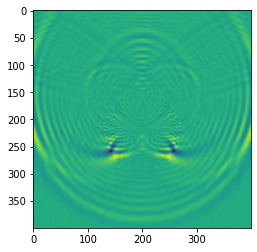

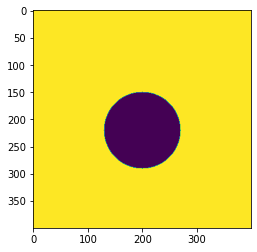

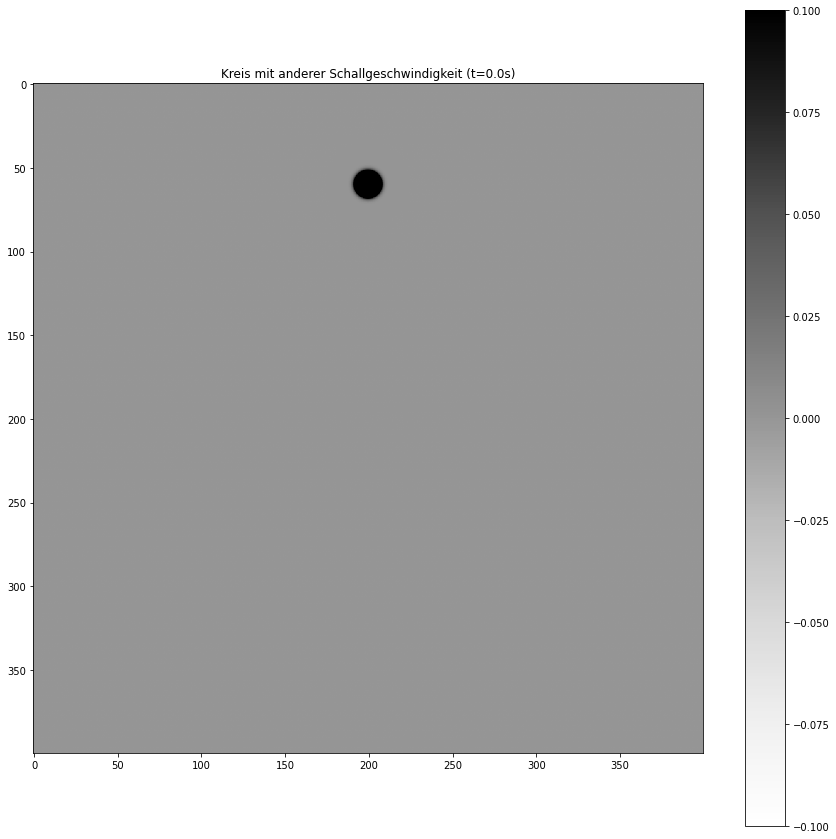

In [3]:
import numpy
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot
import wellen_simulation

heigth = 400
width = 400 #m
d_x = 1 #m
d_y = 1 #m
time = 0.9 #s
d_t = 0.0005

n_x = int(width/d_x)
n_y = int(heigth/d_y)
n_t = int(time/d_t)
seitenverhältnis = n_y/n_x


v = 1000 * numpy.ones((n_y, n_x))
r = 70
for x in range(n_x):
    for y in range(n_y):   
        a = 220
        b = 200
        h = a/d_y - y
        w = b/d_x -x
        if numpy.sqrt((h)**2 + (w)**2) <= r:
            v[y, x] = 600

u = numpy.zeros((n_y, n_x, n_t))

gauss = wellen_simulation.point_source(amplitude_gauss=10, mu_x=0.5, mu_y=0.15, sigma=0.007, n_x=n_x, n_y=n_y)
u[:, :, 0] = gauss
u[:, :, 1] = gauss


u = wellen_simulation.wellen_simulieren_ohne_wände(u, v, n_t, d_t, d_x, d_y)
matplotlib.pyplot.imshow(u[:,:,-1])
matplotlib.pyplot.show()
matplotlib.pyplot.imshow(v)

# Funktion für die Animation
def update(frame):
    print(frame, end='\r')
    im.set_array(u[:,:,frame])
    cbar.mappable.set_array(u[:, :, frame])
    cbar.mappable.set_clim(-0.1,0.1)
    ax.set_title("Kreis mit anderer Schallgeschwindigkeit (t=" + str(numpy.round(frame/n_t, 2)) + "s)")
    return im,
 
# Erstelle das Figure-Objekt und die Axes-Objekte
skalierung = 15
fig, ax = plt.subplots(figsize=(skalierung, skalierung*seitenverhältnis))
im = ax.imshow(u[:,:,-1], cmap='Greys')
cbar = plt.colorbar(im)

# Erstelle die Animation
ani = FuncAnimation(fig, update, frames=n_t, interval=50, blit=True)

# Zeige das Video an
plt.show()
ani.save('Welle durch Kreis.mp4', fps=120, extra_args=['-vcodec', 'libx264'])

<h2>Horizontally layered Medium:</h2>

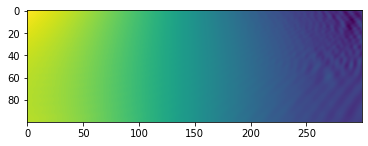

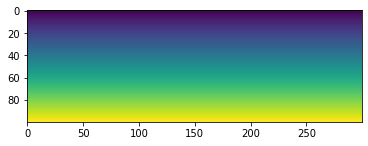

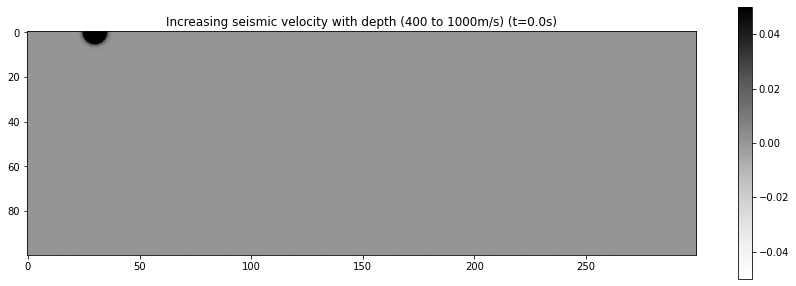

In [23]:
import numpy
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot
import wellen_simulation

heigth = 200
width = 600 #m
d_x = 2 #m
d_y = 2 #m
time = 1.2 #s
d_t = 0.001

n_x = int(width/d_x)
n_y = int(heigth/d_y)
n_t = int(time/d_t)
seitenverhältnis = n_y/n_x


v = numpy.ones((n_y, n_x))
min = 400
max = 1000
for y in range(n_y):  
    v[y, :] = (min+(max-min)*(y/n_y))*numpy.ones((n_x))


u = numpy.zeros((n_y, n_x, n_t))

gauss = wellen_simulation.point_source(amplitude_gauss=1, mu_x=0.1, mu_y=0, sigma=0.007, n_x=n_x, n_y=n_y)
u[:, :, 0] = gauss
u[:, :, 1] = gauss


u = wellen_simulation.wellen_simulieren_ohne_wände(u, v, n_t, d_t, d_x, d_y)
matplotlib.pyplot.imshow(u[:,:,-1])
matplotlib.pyplot.show()
matplotlib.pyplot.imshow(v)

# Funktion für die Animation
def update(frame):
    print(frame, end='\r')
    im.set_array(u[:,:,frame])
    cbar.mappable.set_array(u[:, :, frame])
    cbar.mappable.set_clim(-0.05,0.05)
    ax.set_title("Increasing seismic velocity with depth (400 to 1000m/s) (t=" + str(numpy.round(frame/n_t, 2)) + "s)")
    return im,
 
# Erstelle das Figure-Objekt und die Axes-Objekte
skalierung = 15
fig, ax = plt.subplots(figsize=(skalierung, skalierung*seitenverhältnis))
im = ax.imshow(u[:,:,-1], cmap='Greys')
cbar = plt.colorbar(im)

# Erstelle die Animation
ani = FuncAnimation(fig, update, frames=n_t, interval=50, blit=True)

# Zeige das Video an
plt.show()
ani.save('Layered Medium Wave.mp4', fps=120, extra_args=['-vcodec', 'libx264'])

<h2>Doppelspalt:</h2>

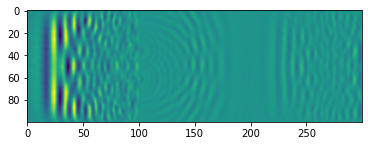

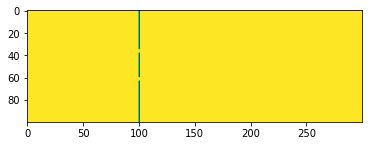

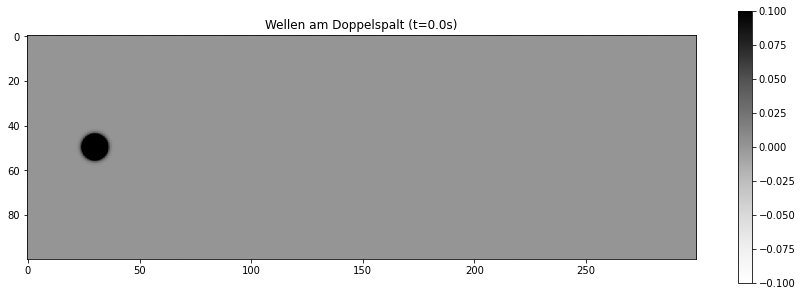

In [22]:
import numpy
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot
import wellen_simulation

heigth = 200
width = 600 #m
d_x = 2 #m
d_y = 2 #m
time = 1.2 #s
d_t = 0.001

n_x = int(width/d_x)
n_y = int(heigth/d_y)
n_t = int(time/d_t)
seitenverhältnis = n_y/n_x


v = 600*numpy.ones((n_y, n_x))
v[:,int(n_x/3)] = 0
v[35:38,int(n_x/3)] = 600
v[60:63,int(n_x/3)] = 600


u = numpy.zeros((n_y, n_x, n_t))

gauss = wellen_simulation.point_source(amplitude_gauss=5, mu_x=0.1, mu_y=0.5, sigma=0.007, n_x=n_x, n_y=n_y)
u[:, :, 0] = gauss
u[:, :, 1] = gauss


u = wellen_simulation.wellen_simulieren_ohne_wände(u, v, n_t, d_t, d_x, d_y)
matplotlib.pyplot.imshow(u[:,:,-1])
matplotlib.pyplot.show()
matplotlib.pyplot.imshow(v)

# Funktion für die Animation
def update(frame):
    print(frame, end='\r')
    im.set_array(u[:,:,frame])
    cbar.mappable.set_array(u[:, :, frame])
    cbar.mappable.set_clim(-0.1,0.1)
    ax.set_title("Wellen am Doppelspalt (t=" + str(numpy.round(frame/n_t, 2)) + "s)")
    return im,
 
# Erstelle das Figure-Objekt und die Axes-Objekte
skalierung = 15
fig, ax = plt.subplots(figsize=(skalierung, skalierung*seitenverhältnis))
im = ax.imshow(u[:,:,-1], cmap='Greys')
cbar = plt.colorbar(im)

# Erstelle die Animation
ani = FuncAnimation(fig, update, frames=n_t, interval=50, blit=True)

# Zeige das Video an
plt.show()
ani.save('Doppelspalt.mp4', fps=120, extra_args=['-vcodec', 'libx264'])

<h2>Erdbeben:</h2>

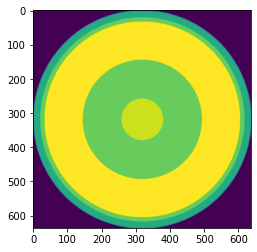

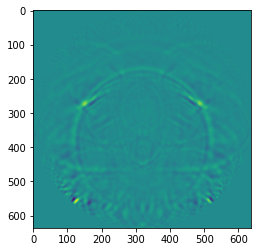

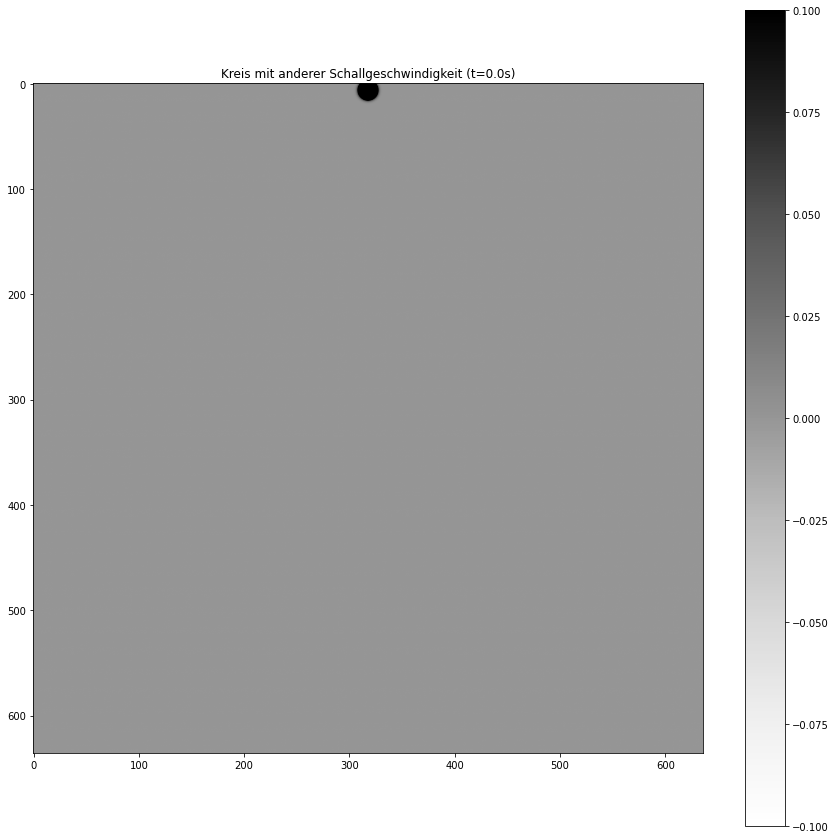

In [ ]:
import numpy
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot
import wellen_simulation

heigth = 2*6369000+1
width = 2*6369000+1 #m
d_x = 20000 #m
d_y = 20000 #m
time = 2000 #s
d_t = 1

n_x = int(width/d_x)
n_y = int(heigth/d_y)
n_t = int(time/d_t)
seitenverhältnis = n_y/n_x


v = numpy.zeros((n_y, n_x))
r_e = 6369000
for x in range(n_x):
    for y in range(n_y):
        a = r_e
        b = r_e
        h = a - y * d_y
        w = b - x * d_x
        p = numpy.sqrt(h**2 + w**2)
        if p <= 6369000:
            v[y, x] = 6000
        if p <= 6369000 - 35000:
            v[y, x] = 8000
        if p <= 6369000 - 410000:
            v[y, x] = 10000
        if p <= 6369000 - 660000:
            v[y, x] = 13000
        if p <= 6369000 - 2889000:
            v[y, x] = 10000
        if p <= 6369000 - 5154000:
            v[y, x] = 12000

matplotlib.pyplot.imshow(v)
matplotlib.pyplot.show()
u = numpy.zeros((n_y, n_x, n_t))

gauss = wellen_simulation.point_source(amplitude_gauss=10, mu_x=0.5, mu_y=0.01, sigma=0.005, n_x=n_x, n_y=n_y)
u[:, :, 0] = gauss
u[:, :, 1] = gauss


u = wellen_simulation.wellen_simulieren_ohne_wände(u, v, n_t, d_t, d_x, d_y)
matplotlib.pyplot.imshow(u[:,:,-1])
matplotlib.pyplot.show()


# Funktion für die Animation
def update(frame):
    print(frame, end='\r')
    im.set_array(u[:,:,frame])
    cbar.mappable.set_array(u[:, :, frame])
    cbar.mappable.set_clim(-0.1,0.1)
    ax.set_title("Kreis mit anderer Schallgeschwindigkeit (t=" + str(numpy.round(frame/n_t, 2)) + "s)")
    return im,
 
# Erstelle das Figure-Objekt und die Axes-Objekte
skalierung = 15
fig, ax = plt.subplots(figsize=(skalierung, skalierung*seitenverhältnis))
im = ax.imshow(u[:,:,-1], cmap='Greys')
cbar = plt.colorbar(im)

# Erstelle die Animation
ani = FuncAnimation(fig, update, frames=n_t, interval=50, blit=True)

# Zeige das Video an
plt.show()
ani.save('Erdbeben1.mp4', fps=120, extra_args=['-vcodec', 'libx264'])